In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Hugging Face

Mounted at /content/gdrive
/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face


In [2]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("markerpensseg/train")
count_images("markerpensseg/valid")

Total images: 225
Total images: 30


In [3]:
# Check train annotations
with open("markerpensseg/train/_annotations.coco.json") as f:
    train_data = json.load(f)
    print(f"Train images: {len(train_data['images'])}")
    print(f"Train annotations: {len(train_data['annotations'])}")
    print(f"Categories: {train_data['categories']}")

# Check validation
with open("markerpensseg/valid/_annotations.coco.json") as f:
    valid_data = json.load(f)
    print(f"\nValid images: {len(valid_data['images'])}")
    print(f"Valid annotations: {len(valid_data['annotations'])}")

Train images: 225
Train annotations: 450
Categories: [{'id': 0, 'name': 'caps-7o2C', 'supercategory': 'none'}, {'id': 1, 'name': 'CAP', 'supercategory': 'caps-7o2C'}]

Valid images: 30
Valid annotations: 60


In [4]:
import json
from collections import defaultdict
from pprint import pprint

def check_coco_instance_segmentation(ann_file_path):
    with open(ann_file_path, 'r') as f:
        coco_data = json.load(f)

    # Top-level keys
    assert 'images' in coco_data, "'images' key not found"
    assert 'annotations' in coco_data, "'annotations' key not found"
    assert 'categories' in coco_data, "'categories' key not found"

    print(f"📷 Total images: {len(coco_data['images'])}")
    print(f"✏️ Total annotations: {len(coco_data['annotations'])}")
    print(f"🏷️ Total categories: {len(coco_data['categories'])}")

    print("\n🔍 Sample category definitions:")
    pprint(coco_data['categories'])

    # Required annotation fields
    required_fields = {"id", "image_id", "bbox", "category_id", "segmentation"}
    optional_fields = ["iscrowd", "area"]
    missing_fields = defaultdict(list)
    bad_segmentations = []

    for i, ann in enumerate(coco_data['annotations']):
        for field in required_fields:
            if field not in ann:
                missing_fields[field].append(i)

        # Check segmentation format: must be non-empty polygon(s)
        seg = ann.get("segmentation", [])
        if not isinstance(seg, list) or len(seg) == 0:
            bad_segmentations.append((i, "Empty or invalid segmentation"))
        else:
            for poly in seg:
                if not isinstance(poly, list) or len(poly) < 6 or len(poly) % 2 != 0:
                    bad_segmentations.append((i, f"Invalid polygon: {poly}"))

    # Report missing fields
    for field, indices in missing_fields.items():
        print(f"⚠️ Missing '{field}' in {len(indices)} annotations. Examples: {indices[:5]}")
    if not missing_fields:
        print("✅ All required fields are present in every annotation")

    # Report segmentation issues
    if bad_segmentations:
        print(f"⚠️ Found {len(bad_segmentations)} invalid/malformed segmentations.")
        for i, reason in bad_segmentations[:5]:
            print(f"  Annotation {i}: {reason}")
    else:
        print("✅ All segmentations are well-formed polygons")

    # Optional fields
    for field in optional_fields:
        missing = sum(1 for ann in coco_data['annotations'] if field not in ann)
        if missing > 0:
            print(f"⚠️ Missing optional '{field}' in {missing} annotations")
        else:
            print(f"✅ All annotations have optional field '{field}'")

# Example usage:
check_coco_instance_segmentation("markerpensseg/train/_annotations.coco.json")

📷 Total images: 225
✏️ Total annotations: 450
🏷️ Total categories: 2

🔍 Sample category definitions:
[{'id': 0, 'name': 'caps-7o2C', 'supercategory': 'none'},
 {'id': 1, 'name': 'CAP', 'supercategory': 'caps-7o2C'}]
✅ All required fields are present in every annotation
✅ All segmentations are well-formed polygons
✅ All annotations have optional field 'iscrowd'
✅ All annotations have optional field 'area'


In [5]:
!git clone https://github.com/facebookresearch/detectron2.git
%cd detectron2

fatal: destination path 'detectron2' already exists and is not an empty directory.
/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face/detectron2


In [ ]:
!pip install -U 'git+https://github.com/facebookresearch/detectron2.git'

In [7]:
import sys
import os
import yaml
import numpy as np
import torch

sys.path.insert(0, '/content/gdrive/MyDrive/Hugging Face/detectron2')

In [8]:
%cd /content/gdrive/MyDrive/Hugging Face/

/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face


In [9]:
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

<Logger detectron2 (DEBUG)>

In [10]:
from detectron2.data.datasets import register_coco_instances
import os

data_dir = "markerpensseg"

register_coco_instances("marker_train", {},
                        os.path.join(data_dir, "train/_annotations.coco.json"),
                        os.path.join(data_dir, "train"))

register_coco_instances("marker_val", {},
                        os.path.join(data_dir, "valid/_annotations.coco.json"),
                        os.path.join(data_dir, "valid"))

In [11]:
import os
import sys
import detectron2

# 1. Define path
root_dir = "/content/gdrive/MyDrive/Hugging Face/detectron2"

# 2. Get the location where detectron2 is installed
d2_pkg_path = os.path.dirname(detectron2.__file__)

# 3. Create a link so the Model Zoo can find 'configs' folder
# This is the "magic" fix for the 'not available in Model Zoo' error
d2_configs_path = os.path.join(d2_pkg_path, "model_zoo", "configs")
if not os.path.exists(d2_configs_path):
    os.symlink(os.path.join(root_dir, "configs"), d2_configs_path)

# 4. Load the config using LazyConfig from the project folder
from detectron2.config import LazyConfig
os.chdir(root_dir)
config_path = "projects/MViTv2/configs/mask_rcnn_mvitv2_t_3x.py"
cfg = LazyConfig.load(config_path)

# 5. Set weights
cfg.train.init_checkpoint = "https://dl.fbaipublicfiles.com/detectron2/MViTv2/mask_rcnn_mvitv2_t_3x/f307611773/model_final_1a1c30.pkl"

print("Config loaded successfully!")

Config loaded successfully!


In [12]:
from detectron2.config import instantiate
from detectron2.checkpoint import DetectionCheckpointer
import torch

# 1. Build the model structure from the config
model = instantiate(cfg.model)
model.to(cfg.train.device) # Usually "cuda"
model.eval()

# 2. Load the pre-trained weights
# This uses the URL we set in the previous step
DetectionCheckpointer(model).load(cfg.train.init_checkpoint)

print("Model is ready for inference!")

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[03/31 14:52:14 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/MViTv2/mask_rcnn_mvitv2_t_3x/f307611773/model_final_1a1c30.pkl ...


model_final_1a1c30.pkl: 175MB [00:07, 22.2MB/s]                           


Model is ready for inference!


In [13]:
%cd /content/gdrive/MyDrive/Hugging Face/

/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face


In [14]:
from detectron2.config import LazyConfig
print(LazyConfig.to_py(cfg))

cfg.constants.imagenet_bgr256_mean=[103.53,116.28,123.675]
cfg.constants.imagenet_bgr256_std=[1.0,1.0,1.0]
cfg.constants.imagenet_rgb256_mean=[123.675,116.28,103.53]
cfg.constants.imagenet_rgb256_std=[58.395,57.12,57.375]
cfg.dataloader.evaluator=detectron2.evaluation.COCOEvaluator(dataset_name='coco_2017_val')
cfg.dataloader.test=detectron2.data.build_detection_test_loader(dataset=detectron2.data.get_detection_dataset_dicts(filter_empty=False, names='coco_2017_val'), mapper=detectron2.data.DatasetMapper(augmentations=[detectron2.data.transforms.ResizeShortestEdge(max_size=1333, short_edge_length=800)], image_format='RGB', is_train=False), num_workers=4)
cfg.dataloader.train=detectron2.data.build_detection_train_loader(dataset=detectron2.data.get_detection_dataset_dicts(names='coco_2017_train'), mapper=detectron2.data.DatasetMapper(augmentations=[detectron2.data.transforms.RandomApply(prob=0.5, tfm_or_aug=detectron2.data.transforms.AugmentationList(augs=[detectron2.data.transforms.Resi

In [15]:
import cv2
cv2.setNumThreads(0)

In [16]:
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.config import LazyConfig

cfg = get_cfg()

# Use MViTv2 Mask R-CNN
cfg = LazyConfig.load("detectron2/projects/MViTv2/configs/mask_rcnn_mvitv2_t_3x.py")
cfg.train.init_checkpoint = "https://dl.fbaipublicfiles.com/detectron2/MViTv2/mask_rcnn_mvitv2_t_3x/f307611773/model_final_1a1c30.pkl"

# 1. Basic Setup & Datasets
cfg.dataloader.train.dataset.names = "marker_train"
cfg.dataloader.test.dataset.names = "marker_val"
cfg.dataloader.train.num_workers = 0

# 2. Training Iterations
num_images = 225
batch_size = 1
epochs = 10 # but only 1 epoch trained
iters_per_epoch = num_images // batch_size

cfg.train.max_iter = iters_per_epoch * epochs
cfg.train.eval_period = iters_per_epoch * 1       # Evaluate every 1
cfg.train.checkpointer.period = iters_per_epoch * 1 # Checkpoint every 1
cfg.dataloader.train.total_batch_size = batch_size

# 3. Optimizer & LR Schedule
cfg.optimizer.lr = 0.00025
cfg.lr_multiplier.scheduler.milestones = [
    int(cfg.train.max_iter * 0.5),
    int(cfg.train.max_iter * 0.8)
]

# 4. Model Head Settings
# MViTv2 LazyConfig mapping:
cfg.model.roi_heads.num_classes = 2

# 5. Output directory
cfg.train.output_dir = "/content/.cache/detectron2_marker"
os.makedirs(cfg.train.output_dir, exist_ok=True)

In [17]:
from detectron2.config import LazyConfig
print(LazyConfig.to_py(cfg))

cfg.constants.imagenet_bgr256_mean=[103.53,116.28,123.675]
cfg.constants.imagenet_bgr256_std=[1.0,1.0,1.0]
cfg.constants.imagenet_rgb256_mean=[123.675,116.28,103.53]
cfg.constants.imagenet_rgb256_std=[58.395,57.12,57.375]
cfg.dataloader.evaluator=detectron2.evaluation.COCOEvaluator(dataset_name='marker_val')
cfg.dataloader.test=detectron2.data.build_detection_test_loader(dataset=detectron2.data.get_detection_dataset_dicts(filter_empty=False, names='marker_val'), mapper=detectron2.data.DatasetMapper(augmentations=[detectron2.data.transforms.ResizeShortestEdge(max_size=1333, short_edge_length=800)], image_format='RGB', is_train=False), num_workers=4)
cfg.dataloader.train=detectron2.data.build_detection_train_loader(dataset=detectron2.data.get_detection_dataset_dicts(names='marker_train'), mapper=detectron2.data.DatasetMapper(augmentations=[detectron2.data.transforms.RandomApply(prob=0.5, tfm_or_aug=detectron2.data.transforms.AugmentationList(augs=[detectron2.data.transforms.ResizeShortes

In [18]:
from detectron2.engine import DefaultTrainer, hooks
from detectron2.evaluation import COCOEvaluator
import torch

from detectron2.evaluation import inference_on_dataset

class BestModelSaver(hooks.EvalHook):
    def __init__(self, eval_period, model, evaluator, val_loader, save_path):
        self.model = model
        self.evaluator = evaluator
        self.val_loader = val_loader
        self.save_path = save_path
        self.best_ap = -1

        def eval_function():
            results = inference_on_dataset(self.model, self.val_loader, self.evaluator)
            if results:
                curr_ap = results["bbox"]["AP"]
                print(f"📈 Eval AP: {curr_ap:.4f} | Best so far: {self.best_ap:.4f}")
                if curr_ap > self.best_ap:
                    print(f"🥇 New best model! Saving to {self.save_path}")
                    torch.save(self.model.state_dict(), self.save_path)
                    self.best_ap = curr_ap
            return results

        super().__init__(eval_period, eval_function)

In [19]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from pycocotools.coco import COCO
import copy

class SafeCOCOEvaluator(COCOEvaluator):
    def _evaluate_predictions_on_coco(self, coco_gt: COCO, coco_results, iou_type):
        # 🔧 Patch missing fields to prevent crashing
        coco_gt.dataset.setdefault("info", {})
        coco_gt.dataset.setdefault("licenses", [])
        coco_gt.createIndex()  # Ensure internal COCO indexing is rebuilt

        coco_dt = coco_gt.loadRes(coco_results)
        return super()._evaluate_predictions_on_coco(coco_gt, coco_dt, iou_type)

In [ ]:
torch.cuda.empty_cache()

In [20]:
from detectron2.config import instantiate
from detectron2.engine import DefaultTrainer, AMPTrainer
from detectron2.checkpoint import DetectionCheckpointer

# 1. Instantiate the Model & Optimizer
model = instantiate(cfg.model)
model.to(cfg.train.device)
cfg.optimizer.params.model = model
optimizer = instantiate(cfg.optimizer)

# 2. Instantiate the Data Loaders
# Instead of build_detection_test_loader, use the lazy config's definition
train_loader = instantiate(cfg.dataloader.train)
# For the val_loader, we copy the test config and change the dataset name if needed
val_loader = instantiate(cfg.dataloader.test)

# 3. Setup the Trainer (AMPTrainer is recommended for ViTDet)
trainer = AMPTrainer(model, train_loader, optimizer)

# 4. Setup Evaluator & Checkpointer
# Use cfg.train.output_dir for the path
# evaluator = SafeCOCOEvaluator("marker_val", cfg, False, output_dir=cfg.train.output_dir)

evaluator = SafeCOCOEvaluator(
    dataset_name="marker_val",
    tasks=("bbox", "segm"),
    distributed=False,
    output_dir=cfg.train.output_dir
)

best_model_path = "datasets/best_MViTv2_marker.pth"

# 5. Register Hooks & Load Weights
trainer.register_hooks([
    BestModelSaver(cfg.train.eval_period, trainer.model, evaluator, val_loader, best_model_path)
])

from pycocotools.coco import COCO
import copy
import json
import time

def patched_loadRes(self, resFile):
    tic = time.time()  # <-- ✅ define it properly now

    # Ensure required dataset fields exist
    if 'info' not in self.dataset:
        self.dataset['info'] = {}
    if 'licenses' not in self.dataset:
        self.dataset['licenses'] = []

    # Load annotation results from file or list
    if isinstance(resFile, str):
        with open(resFile, 'r') as f:
            anns = json.load(f)
    elif isinstance(resFile, list):
        anns = resFile
    else:
        raise TypeError('resFile must be a file path or list of dicts')

    res = COCO()
    res.dataset['info'] = copy.deepcopy(self.dataset['info'])
    res.dataset['licenses'] = copy.deepcopy(self.dataset['licenses'])
    res.dataset['images'] = copy.deepcopy(self.dataset['images'])

    assert isinstance(anns, list), 'Annotations must be a list'
    anns_img_ids = [ann['image_id'] for ann in anns]
    assert set(anns_img_ids).issubset(set(self.getImgIds()))

    # Add missing 'id' and 'area' fields in each annotation
    for idx, ann in enumerate(anns):
        ann.setdefault('id', idx + 1)
        if 'area' not in ann:
            if 'bbox' in ann:
                _, _, w, h = ann['bbox']
                ann['area'] = w * h
            else:
                ann['area'] = 0

    res.dataset['annotations'] = anns
    res.createIndex()
    print(f'Annotations loaded in {time.time() - tic:.2f}s')
    return res

# ✅ Monkey-patch the method
COCO.loadRes = patched_loadRes

WARNING [03/31 15:05:18 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[03/31 15:05:18 d2.data.datasets.coco]: Loaded 225 images in COCO format from markerpensseg/train/_annotations.coco.json
[03/31 15:05:18 d2.data.build]: Removed 0 images with no usable annotations. 225 images left.
[03/31 15:05:18 d2.data.build]: Distribution of instances among all 2 categories:
|  category  | #instances   |  category  | #instances   |
|:----------:|:-------------|:----------:|:-------------|
| caps-7o2C  | 0            |    CAP     | 450          |
|            |              |            |              |
|   total    | 450          |            |              |
[03/31 15:05:18 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in training: [<detectron2.data.transforms.augmentation_impl.RandomApply object at 0x7a98efed1c40>, ResizeShortestEdge(short_edge_length=[480, 512, 544, 576, 608, 640, 672, 704, 736, 768, 800], max_si

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[03/31 15:05:18 d2.evaluation.coco_evaluation]: Fast COCO eval is not built. Falling back to official COCO eval.


/content/gdrive/MyDrive/Hugging Face/detectron2/detectron2/engine/train_loop.py:471: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  grad_scaler = GradScaler()


In [21]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
DetectionCheckpointer(model, save_dir=cfg.train.output_dir).resume_or_load(
    cfg.train.init_checkpoint, resume=False
)

# Start Training
# trainer.train(start_iter, max_iter)
trainer.train(0, cfg.train.max_iter)

[03/31 14:09:07 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/MViTv2/mask_rcnn_mvitv2_t_3x/f307611773/model_final_1a1c30.pkl ...


roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


[03/31 14:09:07 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0331 14:09:12.825000 21677 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[03/31 14:24:22 d2.evaluation.evaluator]: Start inference on 30 batches


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[03/31 14:24:27 d2.evaluation.evaluator]: Inference done 11/30. Dataloading: 0.0012 s/iter. Inference: 0.2002 s/iter. Eval: 0.0215 s/iter. Total: 0.2229 s/iter. ETA=0:00:04
[03/31 14:24:33 d2.evaluation.evaluator]: Inference done 30/30. Dataloading: 0.0021 s/iter. Inference: 0.2408 s/iter. Eval: 0.0256 s/iter. Total: 0.2687 s/iter. ETA=0:00:00
[03/31 14:24:33 d2.evaluation.evaluator]: Total inference time: 0:00:07.530908 (0.301236 s / iter per device, on 1 devices)
[03/31 14:24:33 d2.evaluation.evaluator]: Total inference pure compute time: 0:00:06 (0.240805 s / iter per device, on 1 devices)
[03/31 14:24:33 d2.evaluation.coco_evaluation]: Preparing results for COCO format ...
[03/31 14:24:33 d2.evaluation.coco_evaluation]: Saving results to /content/.cache/detectron2_marker/coco_instances_results.json
[03/31 14:24:33 d2.evaluation.coco_evaluation]: Evaluating predictions with official COCO API...
creating index...
index created!
Annotations loaded in 0.00s
Running per image evaluation

In [31]:
# Stopped at only 1 epoch due to heavy model and cpu ram crashing
# But accuracy already good

In [22]:
from detectron2.config import get_cfg
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.data import build_detection_test_loader
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2 import model_zoo
import os
from detectron2.config import LazyConfig
from detectron2.checkpoint import DetectionCheckpointer
from detectron2.config import instantiate

# 🔧 Setup config
cfg = get_cfg()

# Use MViTv2 Mask R-CNN
cfg = LazyConfig.load("detectron2/projects/MViTv2/configs/mask_rcnn_mvitv2_t_3x.py")
cfg.train.init_checkpoint = "datasets/best_MViTv2_marker.pth"
cfg.dataloader.train.dataset.names = "marker_train"
cfg.dataloader.test.dataset.names = "marker_val"
cfg.dataloader.train.num_workers = 2

cfg.model.roi_heads.num_classes = 2
cfg.model.roi_heads.box_predictor.test_score_thresh = 0.35
cfg.model.roi_heads.box_predictor.test_nms_thresh = 0.3

val_loader = instantiate(cfg.dataloader.test)

model = instantiate(cfg.model)
model.to(cfg.train.device)
DetectionCheckpointer(model).load("datasets/best_MViTv2_marker.pth")
model.eval()

# 🧪 Run evaluation
evaluator = COCOEvaluator("marker_val", tasks=("bbox", "segm"), output_dir="./output")
results = inference_on_dataset(model, val_loader, evaluator)

print("\n📊 Evaluation Results on Saved Best Model:")
print(results)

WARNING [03/31 15:12:18 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[03/31 15:12:18 d2.data.datasets.coco]: Loaded 30 images in COCO format from markerpensseg/valid/_annotations.coco.json
[03/31 15:12:18 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333)]
[03/31 15:12:18 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[03/31 15:12:18 d2.data.common]: Serializing 30 elements to byte tensors and concatenating them all ...
[03/31 15:12:18 d2.data.common]: Serialized dataset takes 0.03 MiB


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[03/31 15:12:18 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from datasets/best_MViTv2_marker.pth ...
[03/31 15:12:26 d2.evaluation.coco_evaluation]: Fast COCO eval is not built. Falling back to official COCO eval.
[03/31 15:12:26 d2.evaluation.evaluator]: Start inference on 30 batches


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0331 15:12:30.874000 3976 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symb

[03/31 15:12:33 d2.evaluation.evaluator]: Inference done 11/30. Dataloading: 0.0013 s/iter. Inference: 0.1966 s/iter. Eval: 0.0196 s/iter. Total: 0.2176 s/iter. ETA=0:00:04
[03/31 15:12:38 d2.evaluation.evaluator]: Inference done 30/30. Dataloading: 0.0029 s/iter. Inference: 0.2356 s/iter. Eval: 0.0253 s/iter. Total: 0.2641 s/iter. ETA=0:00:00
[03/31 15:12:38 d2.evaluation.evaluator]: Total inference time: 0:00:06.661604 (0.266464 s / iter per device, on 1 devices)
[03/31 15:12:38 d2.evaluation.evaluator]: Total inference pure compute time: 0:00:05 (0.235601 s / iter per device, on 1 devices)
[03/31 15:12:39 d2.evaluation.coco_evaluation]: Preparing results for COCO format ...
[03/31 15:12:39 d2.evaluation.coco_evaluation]: Saving results to ./output/coco_instances_results.json
[03/31 15:12:39 d2.evaluation.coco_evaluation]: Evaluating predictions with official COCO API...
creating index...
index created!
Annotations loaded in 0.00s
Running per image evaluation...
Evaluate annotation t

In [23]:
import random
import cv2
import matplotlib.pyplot as plt
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog, DatasetCatalog
import os
import math
from detectron2.data import transforms as T

cfg.model.roi_heads.box_predictor.test_score_thresh = 0.5
cfg.model.roi_heads.box_predictor.test_nms_thresh = 0.3

def run_inference_on_random_images(num_images):
    # Assign fixed colors to each category (DO NOT touch class names)
    fixed_colors = [
        (0, 0, 0),     # bg
        (0, 255, 0),     # green
    ]
    MetadataCatalog.get("marker_val").thing_colors = fixed_colors

    metadata = MetadataCatalog.get("marker_val")
    dataset_dicts = DatasetCatalog.get("marker_val")
    sampled_dicts = random.sample(dataset_dicts, num_images)

    # Prepare grid layout
    cols = 4
    rows = math.ceil(num_images / cols)
    plt.figure(figsize=(cols * 4, 6 * rows))

    resizer = T.ResizeShortestEdge(short_edge_length=800, max_size=1333)

    for idx, d in enumerate(sampled_dicts):
        img_path = d["file_name"]
        img = cv2.imread(img_path)

        height, width = img.shape[:2]
        img_resized = resizer.get_transform(img).apply_image(img)
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

        new_h, new_w = img_resized.shape[:2]

        with torch.no_grad():
            image_tensor = torch.as_tensor(img_rgb.astype("float32").transpose(2, 0, 1))

            inputs = [{
                "image": image_tensor.to(cfg.train.device),
                "height": height,
                "width": width
            }]

            model.eval()
            outputs = model(inputs)[0]

        v = Visualizer(
            img[:, :, ::-1],
            metadata=metadata,
            scale=0.5,
            instance_mode=ColorMode.SEGMENTATION,
        )
        height, width, channels = img.shape
        if width > 800:
            v._default_line_width = 10 # your desired bounding box thickness
            # override default font size:
            v._default_font_size = 60  # increase font size for labels
        else:
            v._default_line_width = 5 # your desired bounding box thickness
            # override default font size:
            v._default_font_size = 20  # increase font size for labels

        # Set mask transparency here:
        v._default_alpha = 0.3  # from 0 (transparent) to 1 (opaque)

        # Draw predictions
        v = v.draw_instance_predictions(outputs["instances"].to("cpu"))

        plt.subplot(rows, cols, idx + 1)
        plt.imshow(v.get_image())
        plt.axis("off")
        plt.title(f"Image {idx + 1}")

    plt.tight_layout()
    plt.show()

WARNING [03/31 15:16:52 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[03/31 15:16:52 d2.data.datasets.coco]: Loaded 30 images in COCO format from markerpensseg/valid/_annotations.coco.json


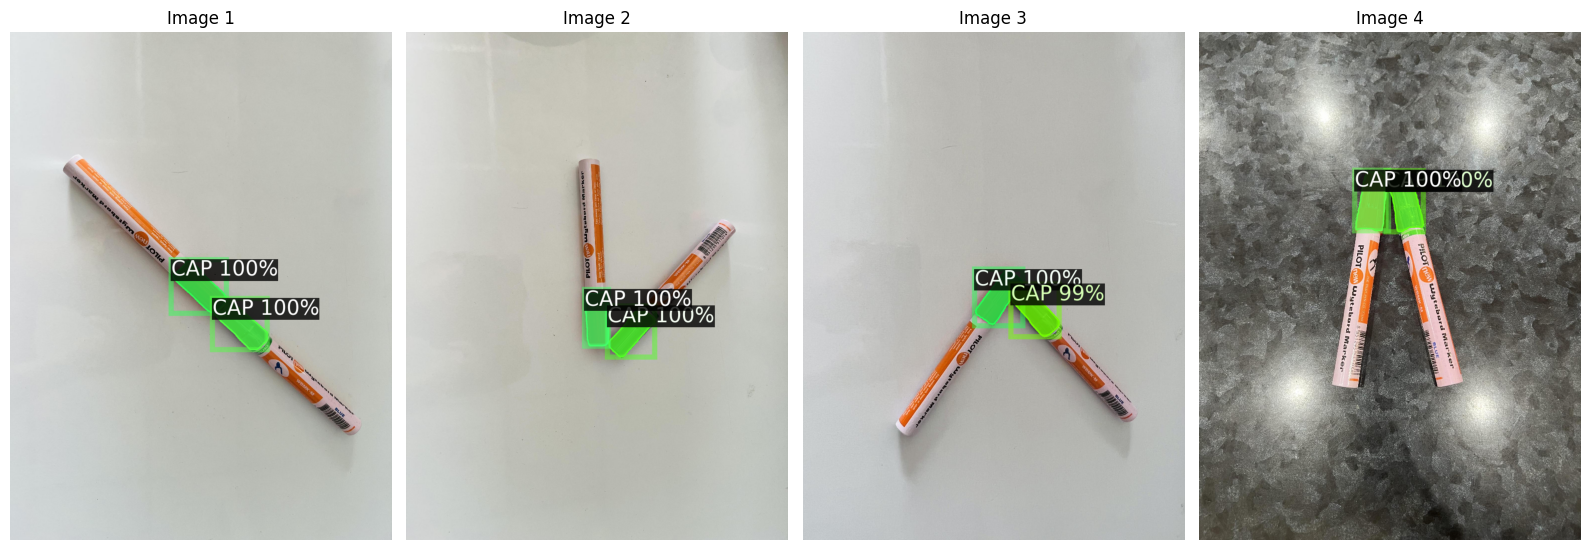

In [24]:
run_inference_on_random_images(4)

In [25]:
import torch
import torch.nn as nn

class D2MaskRCNNWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, image):
        inputs = [{"image": image}]
        images = self.model.preprocess_image(inputs)

        features = self.model.backbone(images.tensor)
        proposals, _ = self.model.proposal_generator(images, features, None)
        results, _ = self.model.roi_heads(images, features, proposals, None)

        inst = results[0]

        masks = inst.pred_masks if inst.has("pred_masks") else torch.empty(0,1,28,28)

        return (
            masks.float(),
            inst.pred_boxes.tensor,
            inst.pred_classes,
            inst.scores,
        )

# Use the wrapper for export
wrapped_model = D2MaskRCNNWrapper(model)
wrapped_model.eval()

D2MaskRCNNWrapper(
  (model): GeneralizedRCNN(
    (backbone): FPN(
      (fpn_lateral2): Conv2d(96, 256, kernel_size=(1, 1), stride=(1, 1))
      (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (fpn_lateral3): Conv2d(192, 256, kernel_size=(1, 1), stride=(1, 1))
      (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (fpn_lateral4): Conv2d(384, 256, kernel_size=(1, 1), stride=(1, 1))
      (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (fpn_lateral5): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1))
      (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (top_block): LastLevelMaxPool()
      (bottom_up): MViT(
        (patch_embed): PatchEmbed(
          (proj): Conv2d(3, 96, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
        )
        (blocks): ModuleList(
          (0): MultiScaleBlock(
            (norm1): LayerNo

In [26]:
dummy = torch.randn(3, 1333, 800).to("cuda")

with torch.no_grad():
    masks, boxes, labels, scores = wrapped_model(dummy)

print("masks:", masks.shape)
print("boxes:", boxes.shape)
print("labels:", labels.shape)
print("scores:", scores.shape)

masks: torch.Size([0, 1, 28, 28])
boxes: torch.Size([0, 4])
labels: torch.Size([0])
scores: torch.Size([0])


In [28]:
import cv2
import torch

img = cv2.imread("markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg")
img = cv2.resize(img, (1333, 800))

img = torch.as_tensor(img.transpose(2,0,1)).float().to("cuda")

with torch.no_grad():
    out = wrapped_model(img)

print(out[0].shape, out[1].shape)

dummy_image = img

torch.Size([2, 1, 28, 28]) torch.Size([2, 4])


In [29]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 20.1 MB/s eta 0:00:00


In [32]:
onnx_model_path = "datasets/best_MViTv2_marker.onnx"

dynamic_axes = {
    "masks": {0: "num_instances"},
    "boxes": {0: "num_instances"},
    "labels": {0: "num_instances"},
    "scores": {0: "num_instances"},
}

torch.onnx.export(
    wrapped_model,
    (dummy_image,),
    onnx_model_path,
    opset_version=17,
    dynamo=False,        # Use legacy exporter to avoid strict tracing issues
    input_names=["input"],
    output_names=["masks", "boxes", "labels", "scores"],
    dynamic_axes=dynamic_axes,
    do_constant_folding=False,
)
print(f"ONNX export {onnx_model_path} completed successfully!")

/tmp/ipykernel_3976/3535450700.py:10: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/content/gdrive/MyDrive/Hugging Face/detectron2/detectron2/structures/image_list.py:86: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert t.shape[:-2] == tensors[0].shape[:-2], t.shape
/content/gdrive/MyDrive/Hugging Face/detectron2/detectron2/modeling/backbone/utils.py:31: TracerWarning: Converting a tensor to a Python boolean might c

ONNX export datasets/best_MViTv2_marker.onnx completed successfully!


In [33]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 6.1 MB/s eta 0:00:00


In [35]:
import onnxruntime
import numpy as np
import cv2
import os
import random
import torch

# Load image and preprocess
img_path = "markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (1333, 800))
img_input = img_resized.astype(np.float32)
img_input = img_input.transpose(2, 0, 1)

# Run inference
session = onnxruntime.InferenceSession("datasets/best_MViTv2_marker.onnx", providers=["CUDAExecutionProvider"])
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: img_input})

# outputs is a list, often like [boxes, scores, keypoints]
print("Output:", [o.shape for o in outputs])

Output: [(2, 1, 28, 28), (2, 4), (2,), (2,)]


[1 1]
[0.9984572  0.99292153]


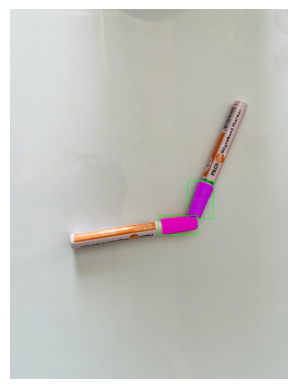

In [36]:
import torch
from torchvision.ops import nms
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Unpack outputs correctly
masks, boxes, labels, scores = outputs

# Convert to numpy arrays if needed
boxes = np.array(boxes)
labels = np.array(labels)
scores = np.array(scores)

# Apply NMS
boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
scores_tensor = torch.tensor(scores, dtype=torch.float32)
nms_indices = nms(boxes_tensor, scores_tensor, iou_threshold=0.5)

# Filter after NMS
boxes = boxes_tensor[nms_indices].numpy()
scores = scores_tensor[nms_indices].numpy()
labels = labels[nms_indices]
masks = masks[nms_indices]
print(labels)
print(scores)

# Resize back to original scale
h_orig, w_orig = img.shape[:2]
scale_x = w_orig / 1333  # width scale
scale_y = h_orig / 800  # height scale

conf_thr = 0.7

for i in range(len(scores)):
    if scores[i] < conf_thr:
        continue

    # Draw bounding box
    x1, y1, x2, y2 = boxes[i]
    x1 = int(x1 * scale_x)
    y1 = int(y1 * scale_y)
    x2 = int(x2 * scale_x)
    y2 = int(y2 * scale_y)

    x1 = max(0, min(x1, w_orig - 1))
    y1 = max(0, min(y1, h_orig - 1))
    x2 = max(0, min(x2, w_orig - 1))
    y2 = max(0, min(y2, h_orig - 1))

    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    mask_28 = masks[i, 0] # Assuming shape is (1, 28, 28)

    # Resize mask to bounding box size
    box_w = max(x2 - x1, 1)
    box_h = max(y2 - y1, 1)

    mask_resized = cv2.resize(mask_28, (box_w, box_h), interpolation=cv2.INTER_LINEAR)
    mask_bool_small = mask_resized > 0.5

    # Paste into full image mask
    mask_bool = np.zeros((h_orig, w_orig), dtype=bool)
    mask_bool[y1:y2, x1:x2] = mask_bool_small[:(y2-y1), :(x2-x1)]

    # Generate color (BGR)
    color = [255,0,255]

    # Create colored mask with the random color
    colored_mask = np.zeros_like(img, dtype=np.uint8)
    for c in range(3):
        colored_mask[:, :, c] = mask_bool * color[c]

    # Alpha blend the colored mask onto the overlay
    alpha = 0.7
    img = np.where(mask_bool[:, :, None],
                      (((1 - alpha) * img) + (alpha * colored_mask)).astype(np.uint8),
                      img)

# Show result
plt.imshow(img)
plt.axis('off')
plt.show()

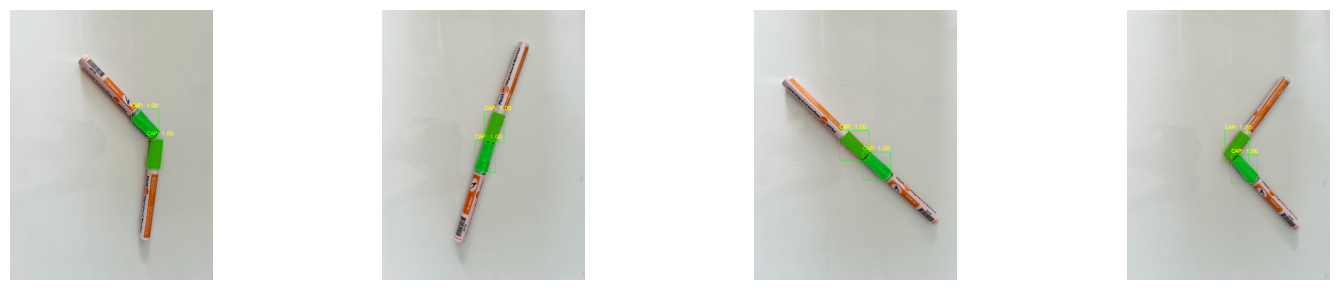

In [38]:
# class names
label_list= ["", "CAP"]

# Assign fixed colors to each category
fixed_colors = [
        (0, 0, 0),     # bg
        (0, 255, 0),     # green
    ]

# ---------------- CONFIG ----------------
val_dir = "markerpensseg/valid/"

# visualization layout
N = 4
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 3 * rows))

for i, image in enumerate(sample_imgs):
    plt.subplot(1, 4, i+1)

    img = cv2.imread(image)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (1333, 800))
    img_input = img_resized.astype(np.float32)
    img_input = img_input.transpose(2, 0, 1)
    input_name = session.get_inputs()[0].name

    outputs = session.run(None, {input_name: img_input})

    masks, boxes, labels, scores = outputs

    # Convert to numpy arrays if needed
    boxes = np.array(boxes)
    labels = np.array(labels)
    scores = np.array(scores)

    # Resize back to original scale
    h_orig, w_orig = img.shape[:2]
    scale_x = w_orig / 1333  # width scale
    scale_y = h_orig / 800  # height scale

    num_det = min(len(boxes), len(masks), len(scores), len(labels))

    boxes = boxes[:num_det]
    scores = scores[:num_det]
    labels = labels[:num_det]
    masks = masks[:num_det]

    # Apply NMS
    boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
    scores_tensor = torch.tensor(scores, dtype=torch.float32)
    nms_indices = nms(boxes_tensor, scores_tensor, iou_threshold=0.5)

    # Filter after NMS
    boxes = boxes_tensor[nms_indices].numpy()
    scores = scores_tensor[nms_indices].numpy()
    labels = labels[nms_indices]
    masks = masks[nms_indices]

    boxes = np.array(boxes)
    scores = np.array(scores).reshape(-1)
    labels = np.array(labels).reshape(-1)
    masks = np.array(masks)

    # ensure dimensions exist
    if boxes.ndim == 1:
        boxes = boxes[None, :]
    if masks.ndim == 3:
        masks = masks[None, :]

    num_det = min(len(boxes), len(masks), len(scores), len(labels))

    boxes = boxes[:num_det]
    scores = scores[:num_det]
    labels = labels[:num_det]
    masks = masks[:num_det]

    conf_thr = 0.1

    keep = scores > conf_thr

    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]
    masks = masks[keep]

    for ii in range(num_det):

        score = scores[ii]

        # Draw bounding box
        x1, y1, x2, y2 = boxes[ii]
        x1 = int(x1 * scale_x)
        y1 = int(y1 * scale_y)
        x2 = int(x2 * scale_x)
        y2 = int(y2 * scale_y)

        x1 = max(0, min(x1, w_orig - 1))
        y1 = max(0, min(y1, h_orig - 1))
        x2 = max(0, min(x2, w_orig - 1))
        y2 = max(0, min(y2, h_orig - 1))

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        mask_28 = masks[ii, 0] # Assuming shape is (1, 28, 28)

        # Resize mask to bounding box size
        box_w = max(x2 - x1, 1)
        box_h = max(y2 - y1, 1)

        mask_resized = cv2.resize(mask_28, (box_w, box_h), interpolation=cv2.INTER_LINEAR)
        mask_bool_small = mask_resized > 0.5

        # Paste into full image mask
        mask_bool = np.zeros((h_orig, w_orig), dtype=bool)
        mask_bool[y1:y2, x1:x2] = mask_bool_small[:(y2-y1), :(x2-x1)]

        # Generate color (BGR)
        label_id = int(labels[ii])
        color = fixed_colors[label_id]

        label = label_list[label_id]

        colored_mask = np.zeros_like(img, dtype=np.uint8)
        colored_mask[mask_bool] = color

        # Alpha blend the colored mask onto the overlay
        alpha = 0.6
        img = np.where(mask_bool[:, :, None],
                          (((1 - alpha) * img) + (alpha * colored_mask)).astype(np.uint8),
                          img)
        # draw label and score
        text = f"{label}: {score:.2f}"
        cv2.putText(img, text, (x1, y1 - 15), cv2.FONT_HERSHEY_SIMPLEX,
                    1.3, (255, 255, 0), 3, cv2.LINE_AA)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# there might be this static shape error even though exported with dynamic shapes
'''
Fail: [ONNXRuntimeError] : 1 : FAIL : Non-zero status code returned while running Split node.
Name:'/roi_heads/mask_head/Split' Status Message: Cannot split using values in 'split' attribute.
Axis=0 Input shape={3,1,28,28} NumOutputs=1 Num entries in 'split' (must equal number of outputs) was 1
Sum of sizes in 'split' (must equal size of selected axis) was 2
'''